# Лабораторная работа № 2

Требуется реализовать алгоритм фильтр частиц для локализации робота при известной карте помещения (заданной в виде массива ячеек) на основе показаний одометрии и измерения расстояния с помощью лазерного дальномера. Робот движется на плоскости, его положение определяется координатами и ориентацией: $(x,y,\theta)$.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Датчики 2/lab2 (2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Датчики 2/lab2 (2)


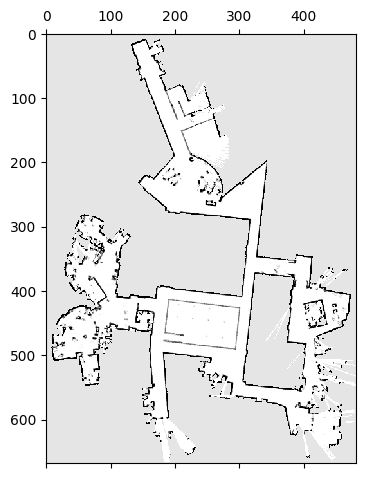

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import lab2 as ex
import tqdm
%matplotlib inline

data = pickle.load(open("dataset_mit_csail.p", "rb"))

plt.matshow(data['img_map'], cmap="gray")
plt.show()

Данные (`data`):

- *img_map* -- карта помещения, в пределах которого движется робот
- *likelihood_map* -- поле правдоподобия, используемое для расчета весов частиц
- *odom* -- зарегистрированные показания одометрии во время движения робота: $\delta_{rot1}, \delta_{trans}, \delta_{rot2}$
- *gt_odom* -- истинные значения одометрии (используется только для проверки результатов)
- *z* измерения дальномера (в каждый момент времени 37 значений $\rho_i, \phi_i$), зарегистрированные во время движения робота, где $\rho_i$ -- расстояние,  $\phi_i$ -- угол сканирования относительно текущей ориентации робота

Пример извлечения данных из `data`:

In [3]:
# get odometry reading at timestep 25
odom_25 = data['odom'][25]
print("Odom at step 25 is: ", odom_25)

# get ground truth odometry reading at timestep 25
odom_gt_25 = data['gt_odom'][25]
print("True odom at step 25 is: ", odom_25)

# get observed scan at timestep 10
z_10 = data['z'][10]
print("Angles at step 10 is: ", z_10[0,:])
print("Ranges at step 10 is: ", z_10[1,:])

Odom at step 25 is:  [ 0.11378333  0.50803543 -0.18586595]
True odom at step 25 is:  [ 0.11378333  0.50803543 -0.18586595]
Angles at step 10 is:  [-1.570796e+00 -1.483526e+00 -1.396256e+00 -1.308986e+00 -1.221716e+00
 -1.134446e+00 -1.047176e+00 -9.599060e-01 -8.726360e-01 -7.853660e-01
 -6.980960e-01 -6.108260e-01 -5.235560e-01 -4.362860e-01 -3.490160e-01
 -2.617460e-01 -1.744760e-01 -8.720600e-02  6.400000e-05  8.733400e-02
  1.746040e-01  2.618740e-01  3.491440e-01  4.364140e-01  5.236840e-01
  6.109540e-01  6.982240e-01  7.854940e-01  8.727640e-01  9.600340e-01
  1.047304e+00  1.134574e+00  1.221844e+00  1.309114e+00  1.396384e+00
  1.483654e+00  1.570924e+00]
Ranges at step 10 is:  [ 3.    2.99  1.33  1.23  1.16  1.14  1.34  1.43  1.4   2.94  3.    3.07
  3.2   3.22  3.59  3.7   3.86  2.75 81.91  1.65  1.68  1.81 81.91 81.91
  4.73  4.76  3.76  4.18  2.3   2.31  5.7   2.33  2.41  4.23  4.09  4.02
 81.91]


## 2.1 Модель движения

Требуется реализовать функцию `sample_motion_model_odometry`, позволяющую прогнозировать положение робота в соответствии с моделью движения на основе одометрии (odometry motion model).

Входные параметры:

- предыдущее положение робота $x_{t-1} = [x,y,\theta]$
- одометрия $u_t = [\delta_{rot1}, \delta_{trans}, \delta_{rot2}]$
- параметры шума $\mathbf{\alpha} = [0.1, 0.1, 0.1, 0.1]$

Функция возвращает сгенерированное предсказанное положение робота.





In [4]:
def sample_motion_model_odometry(xt_prev, ut, alpha = [0.1, 0.1, 0.1, 0.1]):
    x, y, theta = xt_prev
    drot1, dtrans, drot2 = ut
    a1, a2, a3, a4 = alpha

    drot1_hat = drot1 + np.random.normal(0, a1 * abs(drot1) + a2 * abs(dtrans))
    dtrans_hat = dtrans + np.random.normal(0, a3 * abs(dtrans) + a4 * (abs(drot1) + abs(drot2)))
    drot2_hat = drot2 + np.random.normal(0, a1 * abs(drot2) + a2 * abs(dtrans))

    x_new = x + dtrans_hat * np.cos(theta + drot1_hat)
    y_new = y + dtrans_hat * np.sin(theta + drot1_hat)
    theta_new = theta + drot1_hat + drot2_hat

    while theta_new > np.pi:
        theta_new -= 2 * np.pi
    while theta_new < -np.pi:
        theta_new += 2 * np.pi

    return [x_new, y_new, theta_new]

## 2.2 Расчет весов

Функция `compute_weights` рассчитывает веса частиц в соответствии с моделью наблюдения:

$$w_{i,t} = \eta\,p(z_{t}|x_{i,t}).$$

Модель наблюдения задана в виде поля правдоподобия (likelihood field). Значение функции правдоподобия предварительно найдено для каждой ячейки карты.

Вспомогательная функция `ranges2cells` рассчитывает ячейки карты, соответствующие концевым точкам лучей сканирований, найденные по значениям $(\rho, \phi)$.



In [5]:
def compute_weights(ranges, angles, pos, likelihood_map, map_res, min_likelihood=1e-100):
    r_cell = ex.ranges2cells(ranges, angles, pos, likelihood_map, map_res)

    # Ограничиваем координаты пределами карты
    height, width = likelihood_map.shape
    cx_clipped = np.clip(r_cell[0], 0, width - 1)
    cy_clipped = np.clip(r_cell[1], 0, height - 1)

    likelihoods = likelihood_map[cy_clipped, cx_clipped]

    # Заменяем значения за границами на минимальную вероятность
    out_of_bounds = (r_cell[0] < 0) | (r_cell[0] >= width) | (r_cell[1] < 0) | (r_cell[1] >= height)
    likelihoods[out_of_bounds] = min_likelihood

    return np.prod(likelihoods)

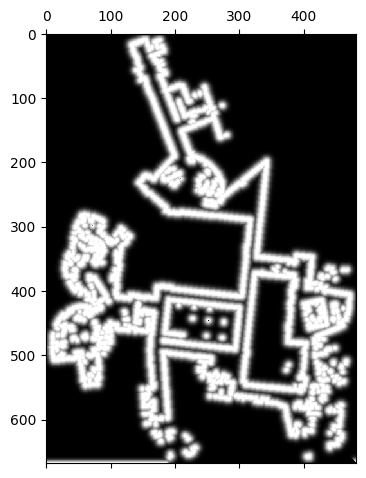

In [6]:
plt.matshow(data['likelihood_map'], cmap="gray")
plt.show()

## 2.3 Ресэмплинг

Tребуется реализовать функцию, выполняющую процедуру ресэмплинга частиц

In [7]:
def resampling(particles, weights):
    N = len(particles)
    indices = np.random.choice(np.arange(N), size=N, p=weights)
    return particles[indices], weights[indices]

In [8]:
def predict_position(particles, weights):
    pred_x, pred_y, pred_theta = 0, 0, 0
    for p, w in zip(particles, weights):
        x, y, theta = p[0:3]
        pred_x += x * w
        pred_y += y * w
        pred_theta += theta * w

    return np.array([pred_x, pred_y, pred_theta])

## 2.4 Локализация

Требуется реализовать алгоритм локализации методом Монте Карло (Monte Carlo localization) в виде функции `mc_localization`, которая последовательно возвращает оценку положения в текущий момент времени на основе одометрии и измерений расстояния.

Число частиц берется равным 5000. Начальное распределение частиц - равномерное.

Разрешение карты (map resolution) полагается равным 0.1



In [9]:
def mc_localization(odometry_t, angles, ranges, particles, weights, likelihood_map):
    height, width = likelihood_map.shape

    for i, p in enumerate(particles):
        # 1. Сэмплируем новое положение
        p[0:3] = sample_motion_model_odometry(p[0:3], odometry_t)

        # 2. Переводим координаты самой частицы в пиксели карты
        cell = ex.poses2cells(p[0:3], data['img_map'], map_res)
        cx, cy = cell[0], cell[1]

        if (cx < 0 or cx >= width or cy < 0 or cy >= height or data['img_map'][cy, cx] == 0):
            weights[i] = 1e-300
        else:
            weights[i] = compute_weights(ranges, angles, p[0:3], likelihood_map, map_res)

    # Нормализация, предсказание и ресэмплинг
    weights /= np.sum(weights)
    estimated_position = predict_position(particles, weights)
    particles, weights = resampling(particles, weights)
    return estimated_position, particles, weights


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm

# Настройки карты
num_particles = 5000
map_res = 0.1

# Инициализация графики (создаем один раз)
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
max_y = np.size(data['img_map'], 0) - 1

# Отображаем карту на заднем фоне
ax.matshow(data['img_map'], cmap="gray")
ax.set_xlim(0, np.size(data['img_map'], 1))
ax.set_ylim(0, np.size(data['img_map'], 0))

# 1. Объект для облака частиц (оранжевые точки)
particle_dots, = ax.plot([], [], '.', color='#ff7f0e', markersize=2, alpha=0.5, label='Частицы')

# 2. Объект для пройденного пути робота (синяя линия)
robot_path, = ax.plot([], [], '-', color='#0000ff', linewidth=1.5, alpha=0.8, label='Траектория')

# 3. Объект для текущего положения робота (крупная синяя точка)
robot_current, = ax.plot([], [], 'o', color='#0000ff', markersize=6, label='Робот')

ax.legend(loc='upper right')

# Начальное состояние данных
particles = ex.init_uniform(num_particles, data['img_map'], map_res)
weights = np.zeros(len(particles)) + 1/len(particles)
likelihood_map = data['likelihood_map']

# Для записи истории позиций для отрисовки линии
history_x = []
history_y = []

# Функция инициализации для анимации
def init():
    particle_dots.set_data([], [])
    robot_path.set_data([], [])
    robot_current.set_data([], [])
    return particle_dots, robot_path, robot_current

# Функция, которая вызывается на каждом шаге (кадре) анимации
def update(t):
    global particles, weights, history_x, history_y

    # Один шаг фильтра частиц
    estimated_position, particles, weights = mc_localization(
        data['odom'][t], data['z'][t][0], data['z'][t][1],
        particles, weights, likelihood_map
    )

    # 1. Обновляем координаты облака частиц
    xs = np.copy(particles[:, 0]) / map_res
    ys = max_y - np.copy(particles[:, 1]) / map_res
    particle_dots.set_data(xs, ys)

    # 2. Обновляем траекторию и текущую позицию робота
    rx = estimated_position[0] / map_res
    ry = max_y - estimated_position[1] / map_res

    history_x.append(rx)
    history_y.append(ry)

    robot_path.set_data(history_x, history_y)
    robot_current.set_data([rx], [ry]) # Передаем как список

    return particle_dots, robot_path, robot_current

total_frames = len(data['odom'])
ani = animation.FuncAnimation(
    fig, update, frames=tqdm(range(total_frames), desc="Создание кадров"),
    init_func=init, blit=True
)

print("Сохранение GIF-анимации...")
ani.save('particle_filter.gif', writer='pillow', fps=15)
plt.close(fig)
print("Готово! Файл 'particle_filter.gif' успешно сохранен.")


Создание кадров:   0%|          | 0/686 [00:00<?, ?it/s]

Сохранение GIF-анимации...


Создание кадров: 100%|█████████▉| 685/686 [11:53<00:01,  1.13s/it]

Готово! Файл 'particle_filter.gif' успешно сохранен.


In [11]:
# result = np.zeros((len(data['odom']), 2))
# for i, e in enumerate(estimated_positions):
#     result[i, 0] = e[0]
#     result[i, 1] = e[1]

In [12]:
# def plot_positions(positions, img_map, map_res):
#     plt.clf()
#     plt.matshow(img_map, cmap="gray")
#     max_y = np.size(img_map, 0) - 1
#     xs = np.copy(positions[:, 0]) / map_res
#     ys = max_y - np.copy(positions[:, 1]) / map_res
#     plt.plot(xs, ys, '.b')
#     plt.xlim(0, np.size(img_map, 1))
#     plt.ylim(0, np.size(img_map, 0))
#     plt.show()

In [13]:
# plot_positions(result, data['img_map'], map_res)

<Figure size 640x480 with 0 Axes>

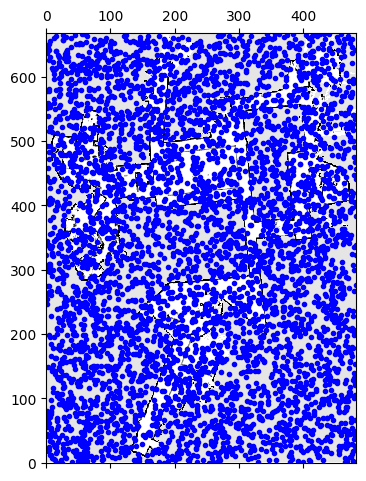

In [14]:
num_particles = 5000
map_res = 0.1
particles = ex.init_uniform(num_particles, data['img_map'], map_res)
ex.plot_particles(particles, data['img_map'], map_res)